<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

<Figure size 1200x800 with 0 Axes>

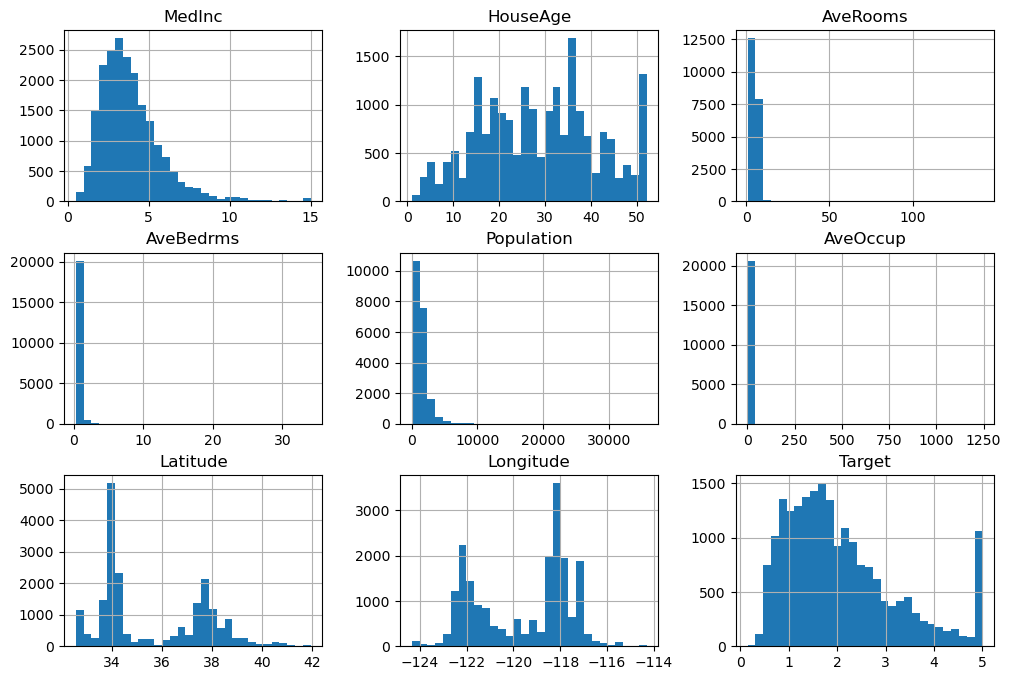

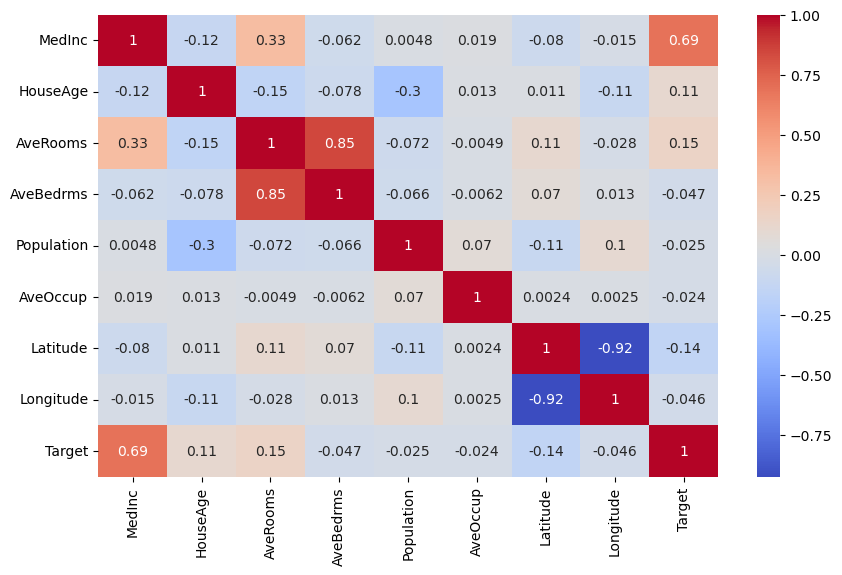

Epoch 1/50
516/516 [==============================] - 2s 3ms/step - loss: 0.5463 - mae: 0.5306 - val_loss: 0.7370 - val_mae: 0.6634
Epoch 2/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4363 - mae: 0.4757 - val_loss: 0.4250 - val_mae: 0.4642
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4178 - mae: 0.4635 - val_loss: 0.3978 - val_mae: 0.4588
Epoch 4/50
516/516 [==============================] - 1s 3ms/step - loss: 0.4011 - mae: 0.4538 - val_loss: 0.5641 - val_mae: 0.5736
Epoch 5/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3859 - mae: 0.4455 - val_loss: 0.3842 - val_mae: 0.4289
Epoch 6/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3882 - mae: 0.4414 - val_loss: 0.3850 - val_mae: 0.4526
Epoch 7/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3733 - mae: 0.4355 - val_loss: 0.3853 - val_mae: 0.4630
Epoch 8/50
516/516 [==============================] - 2s 3ms/step - loss: 0.

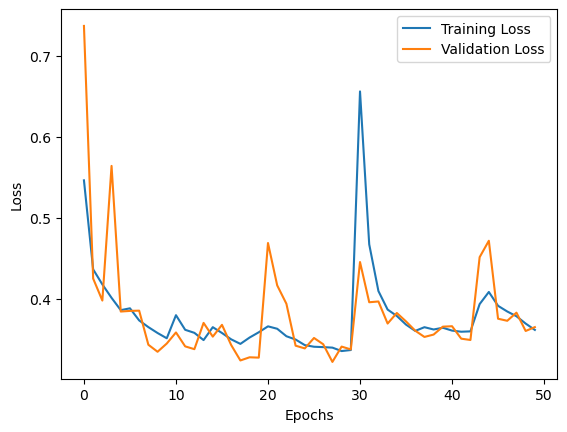

129/129 [==============================] - 0s 2ms/step - loss: 0.3650 - mae: 0.4272
Test MAE: 0.4272279441356659


In [18]:
# ANN with Gradient Descent 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load the dataset
dataset = fetch_california_housing()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model using SGD (Gradient Descent)
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f'Test MAE: {mae}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

<Figure size 1200x800 with 0 Axes>

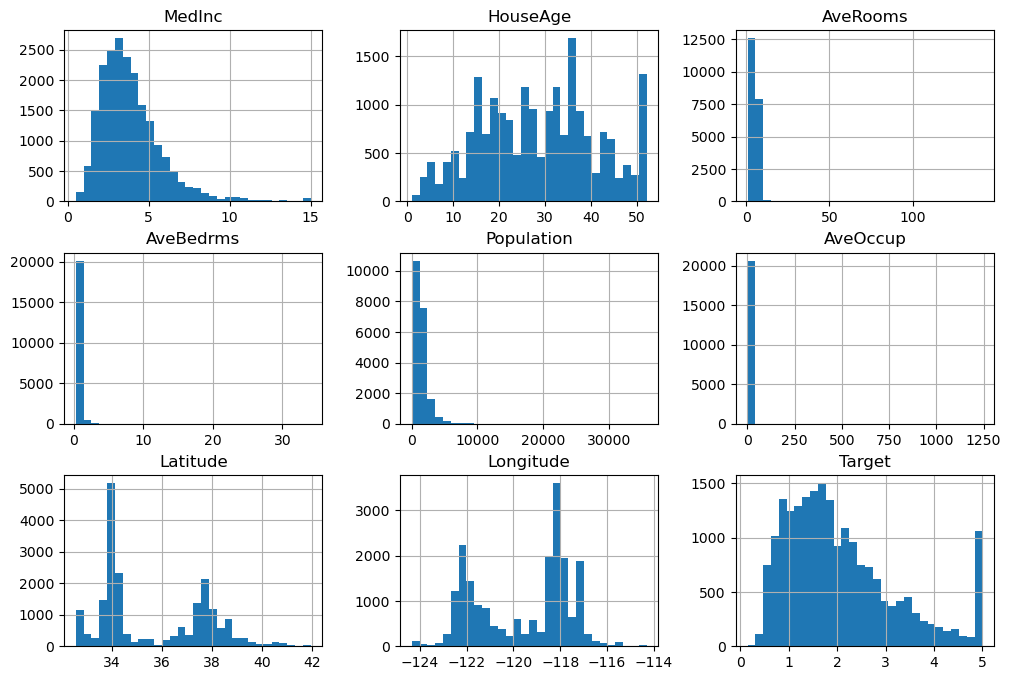

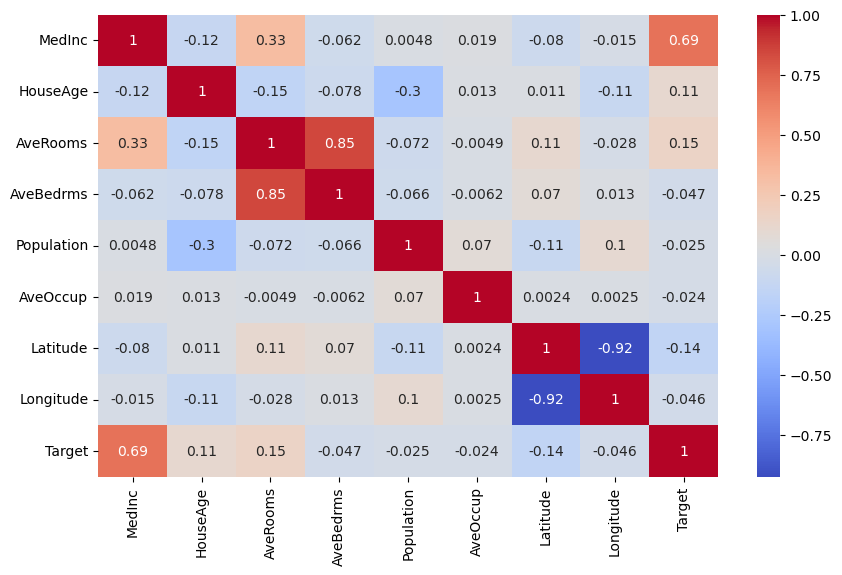

Epoch 1/50
516/516 [==============================] - 2s 3ms/step - loss: 0.7060 - mae: 0.6091 - val_loss: 0.5290 - val_mae: 0.5158
Epoch 2/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4844 - mae: 0.5010 - val_loss: 0.4781 - val_mae: 0.4904
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4462 - mae: 0.4752 - val_loss: 0.4368 - val_mae: 0.4727
Epoch 4/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4269 - mae: 0.4630 - val_loss: 0.4496 - val_mae: 0.4642
Epoch 5/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4114 - mae: 0.4544 - val_loss: 0.4201 - val_mae: 0.4692
Epoch 6/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3980 - mae: 0.4466 - val_loss: 0.4049 - val_mae: 0.4485
Epoch 7/50
516/516 [==============================] - 1s 3ms/step - loss: 0.3871 - mae: 0.4395 - val_loss: 0.3927 - val_mae: 0.4373
Epoch 8/50
516/516 [==============================] - 2s 3ms/step - loss: 0.

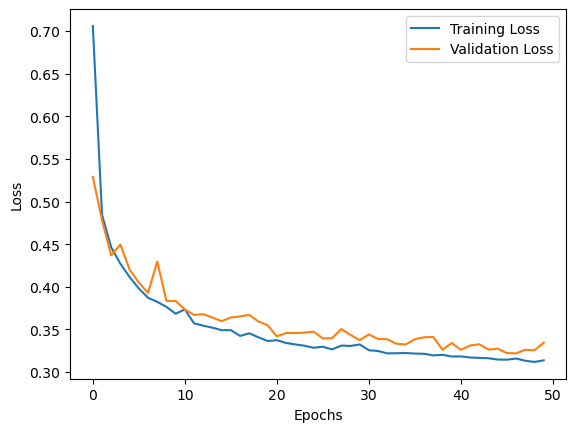

129/129 [==============================] - 0s 2ms/step - loss: 0.3345 - mae: 0.4154
Test MAE: 0.4154224693775177


In [16]:
# ANN with Gradient Descent 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load the dataset
dataset = fetch_california_housing()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model using SGD (Gradient Descent)
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f'Test MAE: {mae}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

<Figure size 1200x800 with 0 Axes>

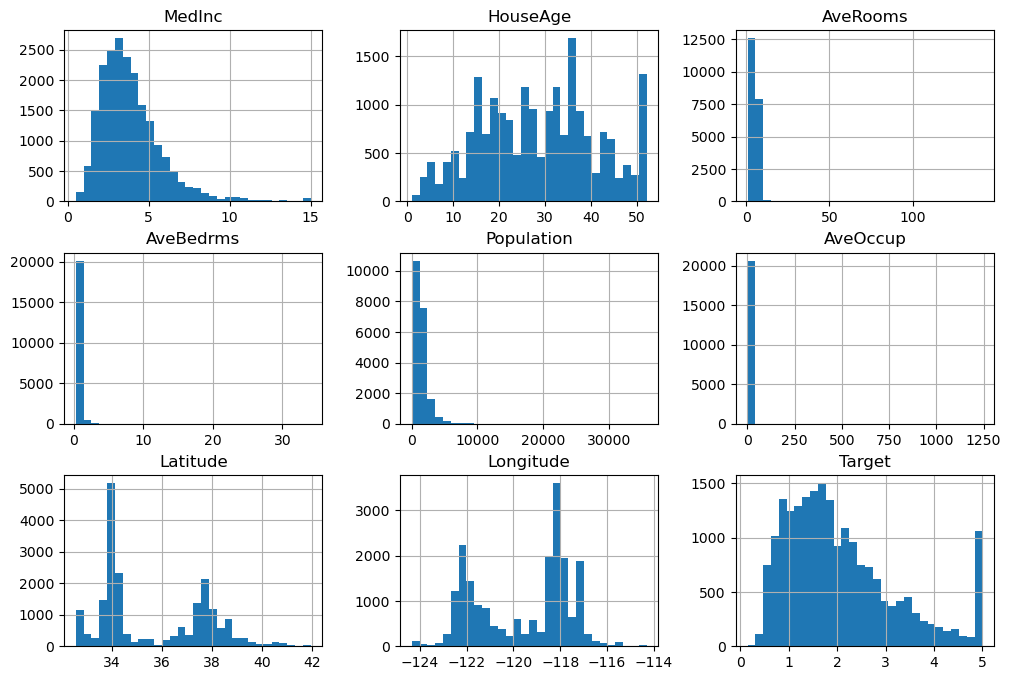

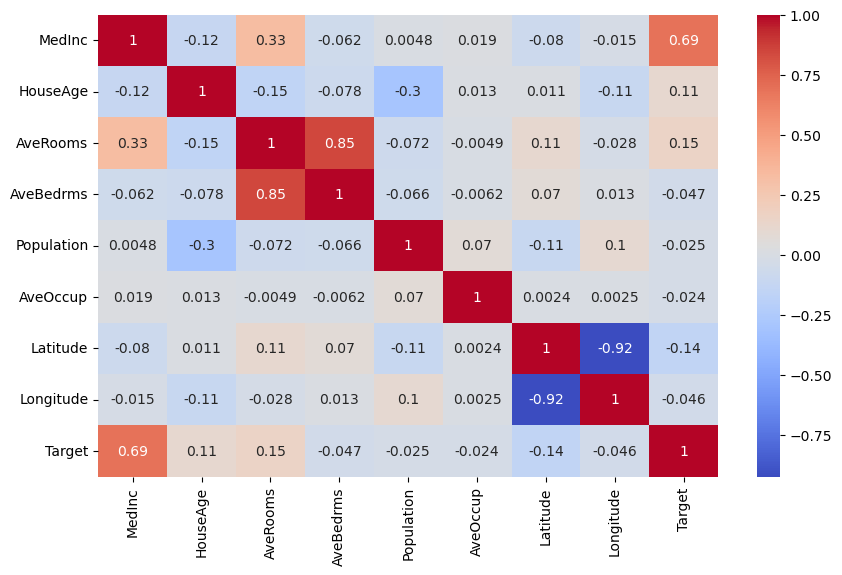

Epoch 1/50
516/516 [==============================] - 2s 3ms/step - loss: 0.6689 - mae: 0.5893 - val_loss: 0.5097 - val_mae: 0.5146
Epoch 2/50
516/516 [==============================] - 1s 3ms/step - loss: 0.4731 - mae: 0.4997 - val_loss: 0.4738 - val_mae: 0.4874
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4378 - mae: 0.4762 - val_loss: 0.4481 - val_mae: 0.4641
Epoch 4/50
516/516 [==============================] - 1s 3ms/step - loss: 0.4173 - mae: 0.4602 - val_loss: 0.4311 - val_mae: 0.4515
Epoch 5/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4022 - mae: 0.4487 - val_loss: 0.4086 - val_mae: 0.4546
Epoch 6/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3928 - mae: 0.4414 - val_loss: 0.4048 - val_mae: 0.4491
Epoch 7/50
516/516 [==============================] - 1s 3ms/step - loss: 0.3872 - mae: 0.4377 - val_loss: 0.3919 - val_mae: 0.4381
Epoch 8/50
516/516 [==============================] - 2s 3ms/step - loss: 0.

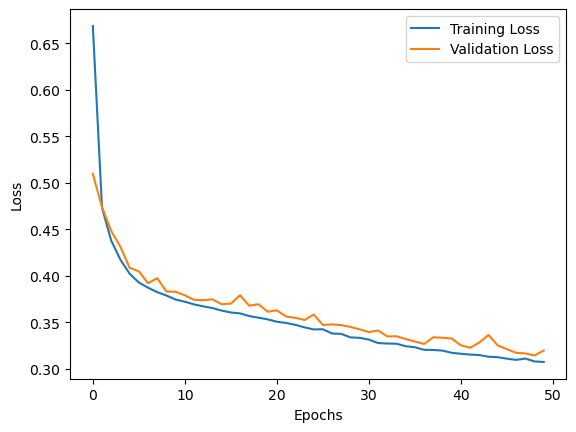

129/129 [==============================] - 0s 2ms/step - loss: 0.3195 - mae: 0.3821
Test MAE: 0.38210541009902954


In [8]:
# ANN with different activation function 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load the dataset
dataset = fetch_california_housing()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model with 'tanh' activation function
model = keras.Sequential([
    layers.Dense(16, activation='tanh', input_shape=(X_train.shape[1],)),  # First hidden layer with 'tanh'
    layers.Dense(8, activation='tanh'),  # Second hidden layer with 'tanh'
    layers.Dense(1)  # Output layer for regression
])

# Compile the model using SGD (Gradient Descent)
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f'Test MAE: {mae}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

<Figure size 1200x800 with 0 Axes>

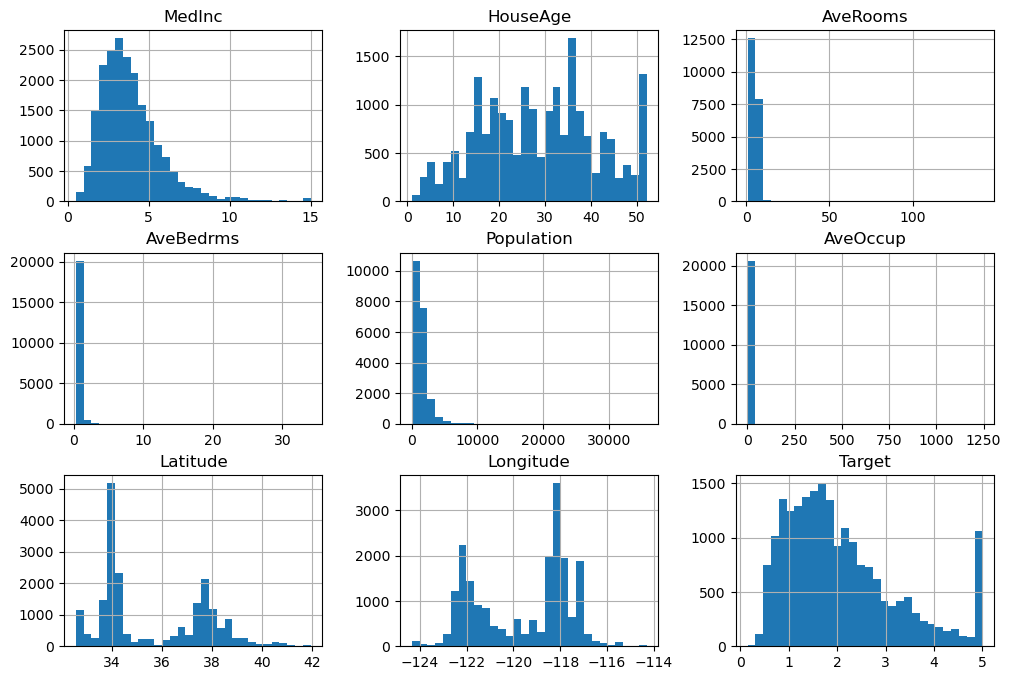

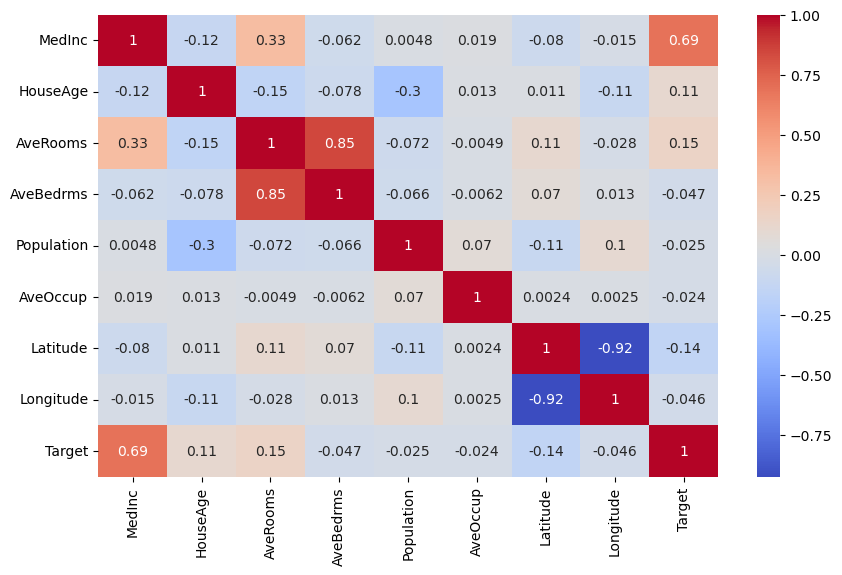

Epoch 1/50
516/516 [==============================] - 3s 4ms/step - loss: 1.5800 - mae: 0.8812 - val_loss: 0.5713 - val_mae: 0.5640
Epoch 2/50
516/516 [==============================] - 2s 3ms/step - loss: 0.5258 - mae: 0.5408 - val_loss: 0.5187 - val_mae: 0.5375
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4837 - mae: 0.5127 - val_loss: 0.4779 - val_mae: 0.5037
Epoch 4/50
516/516 [==============================] - 1s 3ms/step - loss: 0.4592 - mae: 0.4942 - val_loss: 0.4587 - val_mae: 0.5005
Epoch 5/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4444 - mae: 0.4841 - val_loss: 0.4400 - val_mae: 0.4825
Epoch 6/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4269 - mae: 0.4726 - val_loss: 0.4241 - val_mae: 0.4667
Epoch 7/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4072 - mae: 0.4570 - val_loss: 0.4019 - val_mae: 0.4525
Epoch 8/50
516/516 [==============================] - 2s 3ms/step - loss: 0.

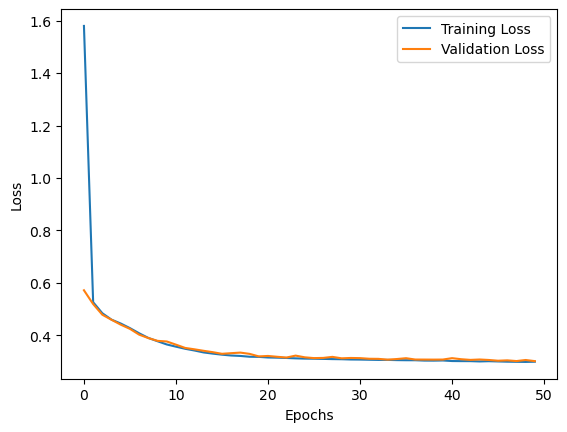

129/129 [==============================] - 0s 3ms/step - loss: 0.3009 - mae: 0.3741
Test MAE: 0.37405216693878174


In [10]:
# ANN with different optimizer 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load the dataset
dataset = fetch_california_housing()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(16, activation='tanh', input_shape=(X_train.shape[1],)),  # First hidden layer with 'tanh'
    layers.Dense(8, activation='tanh'),  # Second hidden layer with 'tanh'
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f'Test MAE: {mae}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

<Figure size 1200x800 with 0 Axes>

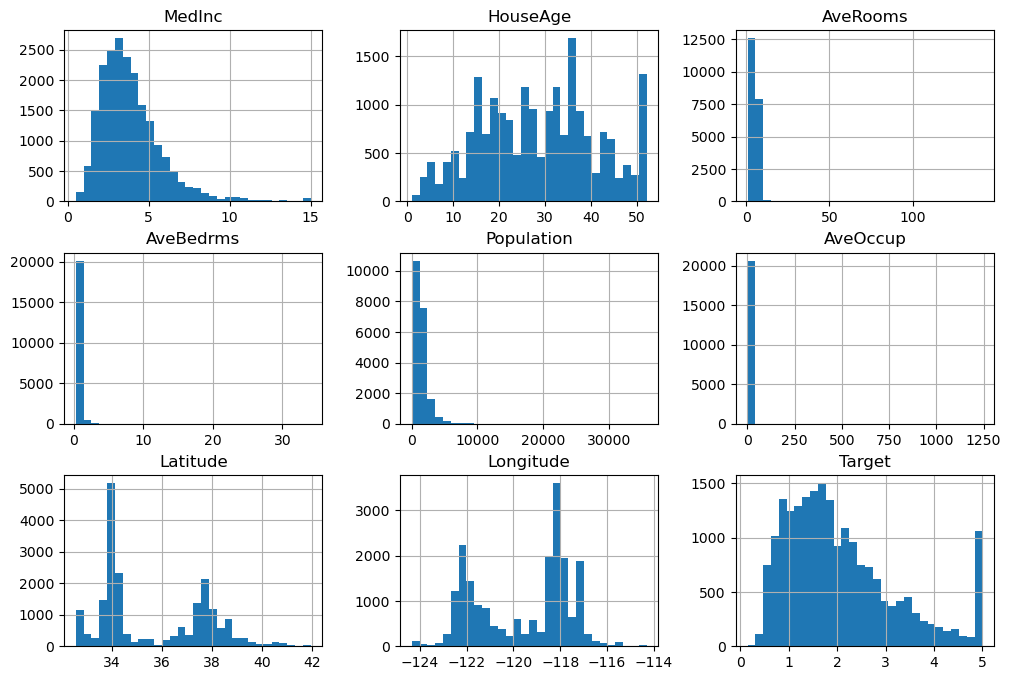

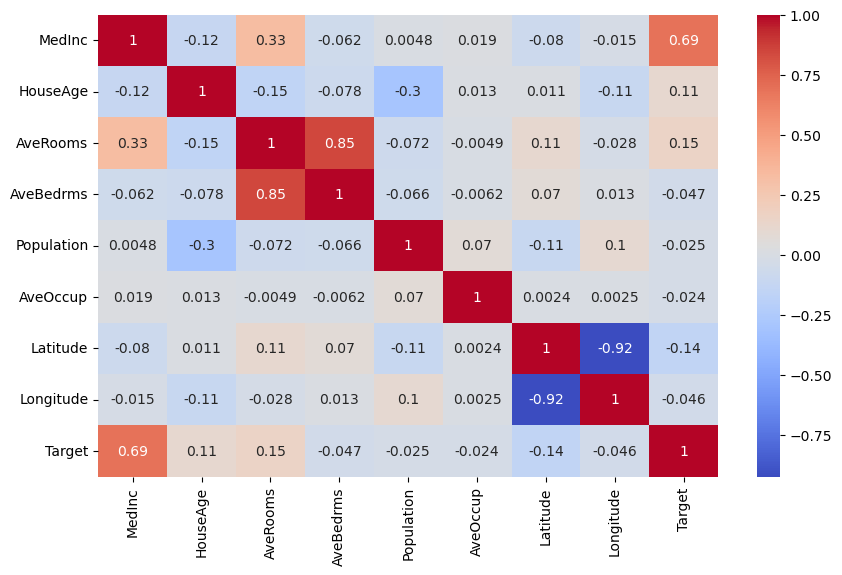

Epoch 1/50
516/516 [==============================] - 2s 3ms/step - loss: 0.7789 - mae: 0.6229 - val_loss: 0.4937 - val_mae: 0.5071
Epoch 2/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4656 - mae: 0.4965 - val_loss: 0.4872 - val_mae: 0.5079
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4501 - mae: 0.4867 - val_loss: 0.4513 - val_mae: 0.4738
Epoch 4/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4374 - mae: 0.4772 - val_loss: 0.4309 - val_mae: 0.4752
Epoch 5/50
516/516 [==============================] - 1s 3ms/step - loss: 0.4186 - mae: 0.4633 - val_loss: 0.4191 - val_mae: 0.4606
Epoch 6/50
516/516 [==============================] - 1s 3ms/step - loss: 0.4044 - mae: 0.4539 - val_loss: 0.4060 - val_mae: 0.4507
Epoch 7/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3866 - mae: 0.4407 - val_loss: 0.3921 - val_mae: 0.4355
Epoch 8/50
516/516 [==============================] - 2s 3ms/step - loss: 0.

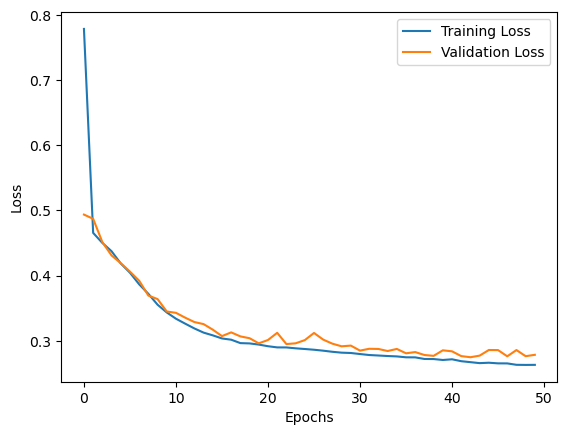

129/129 [==============================] - 0s 2ms/step - loss: 0.2783 - mae: 0.3620
Test MAE: 0.3619987964630127


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load the dataset
dataset = fetch_california_housing()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='tanh'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f'Test MAE: {mae}')
